## 1. Загрузка предобученной модели с весами для тестирования

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
import sys
import time
import numpy as np
from pathlib import Path
from PIL import Image
import torch
import torch.utils.benchmark as benchmark
import matplotlib.pyplot as plt
from tqdm import tqdm
import cv2
from typing import List, Dict, Tuple, Optional
import json

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Создаем структуру папок
!mkdir -p /content/drive/MyDrive/sam3_bdd_project/checkpoints
!mkdir -p /content/drive/MyDrive/sam3_bdd_project/data
!mkdir -p /content/drive/MyDrive/sam3_bdd_project/results

# Клонируем репозиторий
if not os.path.exists('/content/drive/MyDrive/sam3_bdd_project/sam3_repo/sam3'):
    !git clone https://github.com/facebookresearch/sam3.git /content/drive/MyDrive/sam3_bdd_project/sam3_repo/sam3
else:
    print("Репозиторий уже есть")

# Создаем символические ссылки
!ln -sfn /content/drive/MyDrive/sam3_bdd_project/sam3_repo/sam3 /content/sam3
!ln -sfn /content/drive/MyDrive/sam3_bdd_project/checkpoints /content/checkpoints
!ln -sfn /content/drive/MyDrive/sam3_bdd_project/data /content/data
!ln -sfn /content/drive/MyDrive/sam3_bdd_project/results /content/results

# Устанавливаем SAM3
%cd /content/sam3
!pip install -e .
!pip install -e ".[notebooks]"

print("\nПроект настроен!")
print(f"Веса должны быть в: /content/checkpoints/sam3.pt")

Репозиторий уже есть
/content/drive/MyDrive/sam3_bdd_project/sam3_repo/sam3
Obtaining file:///content/drive/MyDrive/sam3_bdd_project/sam3_repo/sam3
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for sam3 (pyproject.toml) ... done
  Created wheel for sam3: filename=sam3-0.1.0-0.editable-py3-none-any.whl size=15403 sha256=b2931bc3f513aef6cf87862459175f23c195261f180cafc9d6763deedd64d0b4
  Stored in directory: /tmp/pip-ephem-wheel-cache-tcd173yc/wheels/07/2a/2f/a39bff2cac07185ca759d735b75aa1e98d7f6335dc6577b11d
Successfully built sam3
  Attempting uninstall: sam3
    Found existing installation: sam3 0.1.0
    Uninstalling sam3-0.1.0:
      Successfully uninstalled sam3-0.1.0
Obtaining file:///content/drive/MyDrive/sam3_bdd_project/sam3_repo/sam3
  Installing build dependencies ... done
  Checking if build backe

In [ ]:
import sam3
print(f"SAM3 установлен по пути: {sam3.__file__}")

SAM3 установлен по пути: /content/drive/MyDrive/sam3_bdd_project/sam3_repo/sam3/sam3/__init__.py


## 2. Загрузка модели с локальными весами с Google Drive

# Сегментация

In [ ]:
import sys
sys.path.append('/content/sam3')

import os
import torch
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import cv2
import gc
import time

# Отключаем обращение к Hugging Face
os.environ['HF_HUB_OFFLINE'] = '1'
os.environ['TRANSFORMERS_OFFLINE'] = '1'
os.environ['HF_DATASETS_OFFLINE'] = '1'

# Модифицируем функцию загрузки с Hugging Face
import sam3.model_builder
original_download_ckpt = sam3.model_builder.download_ckpt_from_hf

def patched_download_ckpt():
    print("⚠️ Hugging Face download disabled, using local checkpoint")
    return '/content/checkpoints/sam3.pt'

sam3.model_builder.download_ckpt_from_hf = patched_download_ckpt

from sam3.model_builder import build_sam3_image_model
from sam3.model.sam3_image_processor import Sam3Processor


class SimpleSAM3:
    """Упрощенный класс для сегментации SAM3 с гибкой системой классов"""

    def __init__(self, checkpoint_path='/content/checkpoints/sam3.pt', resolution=1008):
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        print(f"Using device: {self.device}")

        # Загружаем модель
        self.model = self._load_model(checkpoint_path)
        self.processor = Sam3Processor(
            model=self.model,
            resolution=resolution,
            device=self.device,
            confidence_threshold=0.3
        )

        # Полная цветовая схема BDD100K для GT масок
        self.color_to_class = {
                    # Дорожная инфраструктура
                    (128, 64, 128): 0,      # road
                    (244, 35, 232): 1,      # sidewalk
                    (70, 70, 70): 2,        # building
                    (102, 102, 156): 3,     # wall
                    (190, 153, 153): 4,     # fence
                    (153, 153, 153): 5,     # pole
                    (250, 170, 30): 6,      # traffic light
                    (220, 220, 0): 7,       # traffic sign

                    # Природа
                    (107, 142, 35): 8,      # vegetation
                    (152, 251, 152): 9,     # terrain
                    (70, 130, 180): 10,     # sky

                    # Люди
                    (220, 20, 60): 11,      # person
                    (255, 0, 0): 12,        # rider

                    # Транспорт
                    (0, 0, 142): 13,        # car
                    (0, 0, 70): 14,         # truck
                    (0, 60, 100): 15,       # bus
                    (0, 0, 230): 16,        # trailer
                    (0, 0, 110): 17,        # motorcycle
                    (0, 0, 192): 18,        # bicycle
                    (0, 0, 0): 19,          # train
                }

        # Маппинг промптов на ID классов BDD100K
        self.prompt_to_class_ids = {
            'car': [13], 'truck': [14], 'bus': [15], 'trailer': [16],
            'motorcycle': [17], 'bicycle': [18], 'train': [19],
            'person': [11], 'rider': [12],
            'road': [0], 'sidewalk': [1], 'building': [2], 'wall': [3],
            'fence': [4], 'pole': [5], 'traffic light': [6], 'traffic sign': [7],
            'vegetation': [8], 'terrain': [9], 'sky': [10],
            'vehicle': [13, 14, 15, 16, 17, 18, 19],
            'pedestrian': [11, 12], 'all': list(range(20))
        }

    def clear_memory(self):
        """Очищает память GPU и CPU"""
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            torch.cuda.synchronize()
            torch.cuda.ipc_collect()
        gc.collect()

        try:
            import ctypes
            libc = ctypes.CDLL("libc.so.6")
            libc.malloc_trim(0)
        except:
            pass

    def _load_model(self, checkpoint_path):
        """Загружает модель SAM3"""
        possible_paths = [
            '/content/sam3/sam3/assets/bpe_simple_vocab_16e6.txt.gz',
            '/content/sam3/assets/bpe_simple_vocab_16e6.txt.gz',
        ]

        bpe_path = None
        for path in possible_paths:
            if os.path.exists(path):
                bpe_path = path
                break

        if bpe_path is None:
            raise FileNotFoundError("BPE file not found!")

        model = build_sam3_image_model(
            bpe_path=bpe_path,
            device=self.device,
            eval_mode=True,
            checkpoint_path=checkpoint_path,
            load_from_HF=False,
            enable_segmentation=True,
            enable_inst_interactivity=False,
            compile=False
        )
        return model.to(self.device)

    def _get_class_id_by_name(self, class_name):
      """Получает ID класса BDD100K по имени"""
      mapping = {
          'person': 11, 'rider': 12, 'car': 13, 'truck': 14,
          'bus': 15, 'train': 16, 'motorcycle': 17, 'bicycle': 18,
          'road': 0, 'sidewalk': 1, 'building': 2, 'wall': 3,
          'fence': 4, 'pole': 5, 'traffic light': 6, 'traffic sign': 7,
          'vegetation': 8, 'terrain': 9, 'sky': 10
      }
      return mapping.get(class_name, 0)

    def load_gt_mask(self, mask_path, target_classes=None):
        """
        Загружает GT маску из color_labels для указанных классов

        Args:
            mask_path: путь к маске
            target_classes: список ID классов для извлечения (например [13] для машин, [14] для грузовиков)
                          или None для всех классов
        Returns:
            class_mask: бинарная маска выбранных классов
        """
        mask = np.array(Image.open(mask_path))

        if len(mask.shape) == 3:
            h, w = mask.shape[:2]
            class_mask = np.zeros((h, w), dtype=np.uint8)

            for rgb, class_id in self.color_to_class.items():
                # Если target_classes не указаны - берем все классы
                if target_classes is None or class_id in target_classes:
                    mask_rgb = (mask[:,:,0] == rgb[0]) & \
                               (mask[:,:,1] == rgb[1]) & \
                               (mask[:,:,2] == rgb[2])
                    class_mask[mask_rgb] = 1

            return class_mask
        return mask

    def compute_iou(self, pred_mask, gt_mask):
        """Вычисляет IoU"""
        pred_binary = (pred_mask > 0.5).astype(np.uint8)

        if pred_binary.shape != gt_mask.shape:
            pred_binary = cv2.resize(pred_binary, (gt_mask.shape[1], gt_mask.shape[0]),
                                      interpolation=cv2.INTER_NEAREST)

        intersection = np.logical_and(pred_binary, gt_mask).sum()
        union = np.logical_or(pred_binary, gt_mask).sum()

        if union == 0:
            return 0.0
        return intersection / union

    def morphological_clean(self, mask, kernel_size=5):
        """Морфологическая очистка маски"""
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (kernel_size, kernel_size))
        opened = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
        closed = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, kernel)
        return closed

    def segment(self, image, prompt="car", confidence_threshold=0.3, apply_morphology=True, resize=1008):
        """
        Сегментация изображения по промпту

        Returns:
            combined_mask: объединенная маска всех найденных объектов
            masks: список отдельных масок
            scores: список уверенности
            inference_time: время инференса модели (с)
            total_time: полное время обработки (с)
        """
        original_size = image.size
        image_resized = image.resize((resize, resize))

        # Начало полного замера времени
        total_start = time.perf_counter()

        # Инференс модели
        inference_start = time.perf_counter()
        state = self.processor.set_image(image_resized)
        output = self.processor.set_text_prompt(state=state, prompt=prompt)
        inference_time = time.perf_counter() - inference_start

        masks = output.get("masks")
        scores = output.get("scores")

        # Отладочная информация
        if masks is not None:
            print(f"DEBUG: masks shape = {masks.shape}, dim = {masks.dim()}")
        if scores is not None:
            print(f"DEBUG: scores shape = {scores.shape if hasattr(scores, 'shape') else 'scalar'}")

        if masks is None or masks.numel() == 0:
            print(f"No objects found for prompt: '{prompt}'")
            del state
            self.clear_memory()
            total_time = time.perf_counter() - total_start
            return None, [], [], inference_time, total_time

        # Определяем количество масок в зависимости от размерности
        if masks.dim() == 4:
            # Формат: [batch, channel, height, width]
            num_masks = masks.shape[0]
            print(f"DEBUG: 4D tensor, num_masks={num_masks}, channels={masks.shape[1]}")
        elif masks.dim() == 3:
            # Формат: [num_masks, height, width]
            num_masks = masks.shape[0]
            print(f"DEBUG: 3D tensor, num_masks={num_masks}")
        else:
            # Формат: [height, width] - одна маска
            num_masks = 1
            print(f"DEBUG: 2D tensor, single mask")

        print(f"Found {num_masks} objects for prompt: '{prompt}'")

        all_masks = []
        all_scores = []

        for i in range(num_masks):
            # Безопасное получение confidence
            if scores is not None and scores.numel() > i:
                if hasattr(scores[i], 'item'):
                    conf = float(scores[i].cpu().item())
                else:
                    conf = float(scores[i])
            else:
                conf = 0.0

            if conf < confidence_threshold:
                print(f"  Object {i+1}: confidence={conf:.3f} < threshold={confidence_threshold}, skipping")
                continue

            print(f"  Object {i+1}: confidence={conf:.3f}, processing...")

            # Извлечение маски в зависимости от размерности
            try:
                if masks.dim() == 4:
                    # Формат: [batch, channel, height, width]
                    if masks.shape[1] == 1:
                        # Один канал
                        pred_mask = masks[i, 0, :, :].cpu().numpy()
                    else:
                        # Мультиканальная маска - берем первый канал или среднее
                        pred_mask = masks[i, 0, :, :].cpu().numpy()
                elif masks.dim() == 3:
                    # Формат: [num_masks, height, width]
                    pred_mask = masks[i, :, :].cpu().numpy()
                else:
                    # Формат: [height, width] - одна маска
                    pred_mask = masks.cpu().numpy()
            except Exception as e:
                print(f"  Error extracting mask {i+1}: {e}")
                continue

            # Ресайз к оригинальному размеру
            try:
                # Нормализуем значения если нужно
                if pred_mask.max() > 1.0:
                    pred_mask = pred_mask / 255.0

                mask_pil = Image.fromarray((pred_mask * 255).astype(np.uint8))
                mask_resized = mask_pil.resize(original_size, Image.NEAREST)
                pred_mask = np.array(mask_resized) / 255.0
            except Exception as e:
                print(f"  Error resizing mask {i+1}: {e}")
                continue

            # Бинаризация
            binary_mask = (pred_mask > 0.5).astype(np.uint8)

            # Морфологическая очистка
            if apply_morphology:
                binary_mask = self.morphological_clean(binary_mask)

            all_masks.append(binary_mask)
            all_scores.append(conf)

        # Очищаем промежуточные данные
        del state
        del output
        if masks is not None:
            del masks
        if scores is not None:
            del scores

        # Объединяем все маски
        if all_masks:
            combined_mask = np.zeros_like(all_masks[0])
            for mask in all_masks:
                combined_mask = np.maximum(combined_mask, mask)
            total_time = time.perf_counter() - total_start
            print(f"Successfully processed {len(all_masks)} objects")
            return combined_mask, all_masks, all_scores, inference_time, total_time

        # Если нет масок после фильтрации
        total_time = time.perf_counter() - total_start
        print("No masks passed confidence threshold")
        return None, [], [], inference_time, total_time

    def segment_full_image(self, image, confidence_threshold=0.3):
        """Полная сегментация ВСЕХ 19 классов BDD100K"""

        prompts = {
            'road': 'road surface',
            'sidewalk': 'sidewalk or pavement',
            'building': 'building or house',
            'wall': 'wall or fence wall',
            'fence': 'fence or railing',
            'pole': 'pole or street pole',
            'traffic light': 'traffic light',
            'traffic sign': 'traffic sign or road sign',
            'vegetation': 'vegetation or trees',
            'terrain': 'terrain or ground surface',
            'sky': 'sky',
            'person': 'person',
            'rider': 'rider on motorcycle or bicycle',
            'car': 'car',
            'truck': 'truck',
            'bus': 'bus',
            'train': 'train',
            'motorcycle': 'motorcycle',
            'bicycle': 'bicycle'
        }

        total_start = time.perf_counter()
        results = {}
        combined_mask = np.zeros((image.height, image.width))

        # Для сбора статистики производительности
        class_times = {}
        class_inference_times = {}

        for class_name, prompt_text in prompts.items():
            class_start = time.perf_counter()
            class_id = self._get_class_id_by_name(class_name)

            # Исправлено: segment возвращает 5 значений
            mask, masks, scores, inference_time, seg_time = self.segment(
                image, prompt_text, confidence_threshold
            )

            class_time = time.perf_counter() - class_start

            if mask is not None:
                combined_mask = np.maximum(combined_mask, mask)
                pixels = int((mask > 0).sum())
            else:
                mask = np.zeros((image.height, image.width))
                pixels = 0

            results[class_name] = {
                'mask': mask,
                'class_id': class_id,
                'num_objects': len(masks) if masks else 0,
                'scores': scores if scores else [],
                'pixels': pixels,
                'inference_time_ms': inference_time * 1000,  # время инференса для класса
                'total_time_ms': seg_time * 1000             # полное время для класса
            }

            class_times[class_name] = class_time
            class_inference_times[class_name] = inference_time

        total_time = time.perf_counter() - total_start

        # Вывод статистики производительности
        print(f"\n{'='*60}")
        print("FULL SEGMENTATION PERFORMANCE")
        print(f"{'='*60}")
        print(f"Total time for all {len(prompts)} classes: {total_time*1000:.2f} ms")
        print(f"Average time per class: {total_time/len(prompts)*1000:.2f} ms")
        print(f"Overall FPS (full image): {1.0/total_time:.2f}")
        print(f"{'='*60}")

        return results, combined_mask, total_time

    def visualize_full_segmentation(self, image, full_segmentation, all_masks_combined):
        """
        Визуализация полной сегментации

        Args:
            image: исходное изображение
            full_segmentation: словарь с масками для каждого класса
            all_masks_combined: объединенная маска с ID классов
        """
        # Цветовая схема для визуализации (RGB)
        class_colors = {
            'car': (255, 0, 0),        # Красный
            'truck': (0, 255, 0),      # Зеленый
            'bus': (0, 0, 255),        # Синий
            'trailer': (255, 255, 0),  # Желтый
            'motorcycle': (255, 0, 255), # Пурпурный
            'bicycle': (0, 255, 255),    # Голубой
            'train': (128, 0, 128),      # Фиолетовый
            'person': (255, 128, 0),     # Оранжевый
            'rider': (0, 128, 255),      # Светло-синий
            'road': (128, 128, 128),
            'sidewalk': (200, 200, 200),
            'building': (100, 100, 100),
            'sky': (135, 206, 235),
            'vegetation': (0, 128, 0),
            'traffic light': (255, 255, 0),
            'traffic sign': (255, 165, 0)
        }

        # Создаем цветную маску
        colored_mask = np.zeros((all_masks_combined.shape[0], all_masks_combined.shape[1], 3), dtype=np.uint8)

        for class_name, class_data in full_segmentation.items():
            if class_data['num_objects'] > 0:
                color = class_colors.get(class_name, (255, 255, 255))
                mask_bool = class_data['mask'] > 0
                colored_mask[mask_bool] = color

        # Визуализация
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))

        # 1. Оригинальное изображение
        axes[0, 0].imshow(image)
        axes[0, 0].set_title("Original Image")
        axes[0, 0].axis('off')

        # 2. Полная сегментация (цветная)
        axes[0, 1].imshow(colored_mask)
        axes[0, 1].set_title("Full Segmentation (All Classes)")
        axes[0, 1].axis('off')

        # 3. Наложение на изображение
        overlay = np.array(image) * 0.5 + colored_mask * 0.5
        axes[0, 2].imshow(overlay.astype(np.uint8))
        axes[0, 2].set_title("Overlay")
        axes[0, 2].axis('off')

        # 4. Статистика по классам (bar chart)
        class_names = []
        pixel_counts = []
        object_counts = []

        for class_name, class_data in full_segmentation.items():
            if class_data['pixels'] > 0:
                class_names.append(class_name)
                pixel_counts.append(class_data['pixels'])
                object_counts.append(class_data['num_objects'])

        if class_names:
            x = np.arange(len(class_names))
            width = 0.35

            axes[1, 0].bar(x - width/2, pixel_counts, width, label='Pixel Count', color='skyblue')
            axes[1, 0].set_xlabel('Class')
            axes[1, 0].set_ylabel('Pixel Count')
            axes[1, 0].set_title('Pixel Coverage by Class')
            axes[1, 0].set_xticks(x)
            axes[1, 0].set_xticklabels(class_names, rotation=45)

            axes[1, 1].bar(x + width/2, object_counts, width, label='Object Count', color='lightcoral')
            axes[1, 1].set_xlabel('Class')
            axes[1, 1].set_ylabel('Object Count')
            axes[1, 1].set_title('Number of Objects by Class')
            axes[1, 1].set_xticks(x)
            axes[1, 1].set_xticklabels(class_names, rotation=45)

        # 5. Легенда
        legend_elements = []
        for class_name in class_names:
            color = class_colors.get(class_name, (255, 255, 255))
            color_rgb = tuple(c/255 for c in color)
            legend_elements.append(plt.Rectangle((0, 0), 1, 1, facecolor=color_rgb, label=class_name))

        axes[1, 2].axis('off')
        axes[1, 2].legend(handles=legend_elements, loc='center', fontsize=10)
        axes[1, 2].set_title('Classes Legend')

        plt.tight_layout()
        plt.show()

        return colored_mask

    def compare_with_gt_full(self, full_segmentation, gt_mask_path, target_classes=None):
        """Сравнение полной сегментации с Ground Truth (возвращает JSON-совместимые типы)"""

        gt_mask_full = np.array(Image.open(gt_mask_path))
        metrics = {}

        for class_name, class_data in full_segmentation.items():
            if target_classes and class_name not in target_classes:
                continue

            class_id = class_data['class_id']

            gt_mask_class = np.zeros_like(gt_mask_full[:,:,0] if len(gt_mask_full.shape) == 3 else gt_mask_full, dtype=np.uint8)

            if len(gt_mask_full.shape) == 3:
                for rgb, cid in self.color_to_class.items():
                    if cid == class_id:
                        mask_rgb = (gt_mask_full[:,:,0] == rgb[0]) & \
                                  (gt_mask_full[:,:,1] == rgb[1]) & \
                                  (gt_mask_full[:,:,2] == rgb[2])
                        gt_mask_class[mask_rgb] = 1

            pred_mask = class_data['mask']
            iou = float(self.compute_iou(pred_mask, gt_mask_class))  # конвертируем в float

            pred_pixels = int(class_data['pixels'])  # конвертируем в int
            gt_pixels = int(gt_mask_class.sum())  # конвертируем в int

            precision = float(class_data['num_objects'] / (class_data['num_objects'] + 1e-6))  # конвертируем в float

            metrics[class_name] = {
                'iou': iou,
                'pred_pixels': pred_pixels,
                'gt_pixels': gt_pixels,
                'num_objects_pred': int(class_data['num_objects']),
                'precision': precision
            }

            print(f"\n{class_name.upper()}:")
            print(f"  IoU: {iou:.4f}")
            print(f"  GT pixels: {gt_pixels}, Pred pixels: {pred_pixels}")
            print(f"  Objects: {class_data['num_objects']}")

        if metrics:
            miou = float(np.mean([m['iou'] for m in metrics.values()]))  # конвертируем в float
            print(f"\n{'='*60}")
            print(f"mIoU (mean IoU across classes): {miou:.4f}")
            print(f"{'='*60}")

        return metrics

    def visualize_class_comparison(self, image, full_segmentation, gt_mask_path):
        """
        Визуализация сравнения предсказаний с GT для каждого класса
        """
        # Загружаем GT
        gt_mask_full = np.array(Image.open(gt_mask_path))

        # Определяем классы с объектами
        active_classes = [name for name, data in full_segmentation.items() if data['num_objects'] > 0]
        n_classes = len(active_classes)

        if n_classes == 0:
            print("No objects detected")
            return

        # Создаем сетку для визуализации
        fig, axes = plt.subplots(n_classes, 3, figsize=(15, 4*n_classes))
        if n_classes == 1:
            axes = axes.reshape(1, -1)

        for idx, class_name in enumerate(active_classes):
            class_data = full_segmentation[class_name]
            class_id = class_data['class_id']

            # Создаем GT маску для этого класса
            gt_mask_class = np.zeros_like(gt_mask_full[:,:,0] if len(gt_mask_full.shape) == 3 else gt_mask_full, dtype=np.uint8)

            if len(gt_mask_full.shape) == 3:
                for rgb, cid in self.color_to_class.items():
                    if cid == class_id:
                        mask_rgb = (gt_mask_full[:,:,0] == rgb[0]) & \
                                  (gt_mask_full[:,:,1] == rgb[1]) & \
                                  (gt_mask_full[:,:,2] == rgb[2])
                        gt_mask_class[mask_rgb] = 1

            # Вычисляем IoU
            iou = self.compute_iou(class_data['mask'], gt_mask_class)

            # Визуализация
            axes[idx, 0].imshow(class_data['mask'], cmap='viridis')
            axes[idx, 0].set_title(f"{class_name} - Predicted\n{class_data['num_objects']} objects")
            axes[idx, 0].axis('off')

            axes[idx, 1].imshow(gt_mask_class, cmap='viridis')
            axes[idx, 1].set_title(f"{class_name} - Ground Truth\n{gt_mask_class.sum()} pixels")
            axes[idx, 1].axis('off')

            # Разница
            diff_mask = np.zeros_like(class_data['mask'], dtype=np.uint8)
            diff_mask[(class_data['mask'] > 0) & (gt_mask_class == 0)] = 1  # False Positive
            diff_mask[(class_data['mask'] == 0) & (gt_mask_class > 0)] = 2  # False Negative

            cmap_diff = plt.cm.colors.ListedColormap(['black', 'red', 'blue'])
            axes[idx, 2].imshow(diff_mask, cmap=cmap_diff, vmin=0, vmax=2)
            axes[idx, 2].set_title(f"{class_name} - Difference\nRed=FP, Blue=FN, IoU={iou:.3f}")
            axes[idx, 2].axis('off')

        plt.tight_layout()
        plt.show()

    def test_image(self, image_path, mask_path, prompt="car", confidence_threshold=0.3, resize = 1008):
        """
        Тестирует на одном изображении

        Args:
            image_path: путь к изображению
            mask_path: путь к GT маске
            prompt: текстовый промпт для SAM3
            confidence_threshold: порог уверенности
        """
        print(f"\n{'='*60}")
        print(f"Testing: {Path(image_path).name}")
        print(f"Prompt: '{prompt}', Threshold: {confidence_threshold}")

        # Определяем целевые классы для GT на основе промпта
        target_classes = self.prompt_to_class_ids.get(prompt.lower(), [13])  # по умолчанию car
        class_names = [k for k, v in self.prompt_to_class_ids.items() if v == target_classes][0] if target_classes in self.prompt_to_class_ids.values() else prompt

        print(f"GT target classes: {class_names} (IDs: {target_classes})")
        print(f"{'='*60}")

        iou = None
        fig = None
        image = None
        gt_mask = None
        pred_mask = None
        masks = None
        scores = None

        try:
            # Загружаем изображение
            image = Image.open(image_path).convert('RGB')

            # Загружаем GT маску для соответствующих классов
            gt_mask = self.load_gt_mask(mask_path, target_classes=target_classes)
            gt_pixels = gt_mask.sum()
            print(f"GT {class_names} pixels: {gt_pixels}")

            if gt_pixels == 0:
                print(f"No {class_names} in GT")
                return None

            # Сегментация
            start_time = time.perf_counter()
            pred_mask, masks, scores, inference_time, total_time = self.segment(
                image, prompt, confidence_threshold, resize=resize
            )

            if pred_mask is None:
                print("No objects detected")
                return None

            print(f"Detected: {len(masks)} objects")
            for i, score in enumerate(scores):
                print(f"  Object {i+1}: confidence = {score:.3f}")

            # Вычисляем IoU
            iou = self.compute_iou(pred_mask, gt_mask)
            print(f"\nIoU ({prompt} vs {class_names}): {iou:.4f}")

            print(f"Inference time: {inference_time*1000:.2f} ms")
            print(f"Total processing time: {total_time*1000:.2f} ms")
            print(f"FPS: {1.0/total_time:.2f}")

            # Визуализация
            fig, axes = plt.subplots(1, 4, figsize=(20, 5))

            axes[0].imshow(image)
            axes[0].set_title("Original Image")
            axes[0].axis('off')

            axes[1].imshow(pred_mask, cmap='viridis')
            axes[1].set_title(f"Predicted: {prompt}\n{len(masks)} objects")
            axes[1].axis('off')

            axes[2].imshow(gt_mask, cmap='viridis')
            axes[2].set_title(f"Ground Truth: {class_names}\n{gt_pixels} pixels")
            axes[2].axis('off')

            # Визуализация наложения
            overlay = np.array(image.copy())
            pred_overlay = (pred_mask * 255).astype(np.uint8)
            contour, _ = cv2.findContours(pred_overlay, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            cv2.drawContours(overlay, contour, -1, (0, 255, 0), 2)

            axes[3].imshow(overlay)
            axes[3].set_title(f"Overlay (Green = {prompt})\nIoU = {iou:.3f}")
            axes[3].axis('off')

            plt.tight_layout()
            plt.show()

        except Exception as e:
            print(f"Error: {e}")
            import traceback
            traceback.print_exc()

        finally:
            # Очистка памяти
            if fig is not None:
                plt.close(fig)
            plt.close('all')

            for var in ['image', 'gt_mask', 'pred_mask', 'masks', 'scores']:
                if var in locals() and locals()[var] is not None:
                    del locals()[var]

            self.clear_memory()
            for _ in range(3):
                gc.collect()

        return iou

    def test_image_with_timing(self, image_path, mask_path, prompt="car", confidence_threshold=0.3, resize=1008):
        """Тестирует на одном изображении с замером времени"""

        print(f"\n{'='*60}")
        print(f"Testing: {Path(image_path).name}")
        print(f"Prompt: '{prompt}', Threshold: {confidence_threshold}")

        target_classes = self.prompt_to_class_ids.get(prompt.lower(), [13])
        class_names = prompt
        for name, class_ids in self.prompt_to_class_ids.items():
            if class_ids == target_classes:
                class_names = name
                break

        print(f"Target classes: {class_names} (IDs: {target_classes})")

        try:
            # Загружаем изображение
            image = Image.open(image_path).convert('RGB')

            # Загружаем GT маску
            gt_mask = self.load_gt_mask(mask_path, target_classes=target_classes)
            gt_pixels = gt_mask.sum()

            print(f"GT {class_names} pixels: {gt_pixels}")

            if gt_pixels == 0:
                print(f"No {class_names} in GT mask")
                return None

            # Единый замер времени
            total_start = time.perf_counter()
            pred_mask, masks, scores, inference_time, total_time = self.segment(
                image, prompt, confidence_threshold, resize=resize
            )

            # Проверяем, что сегментация прошла успешно
            if pred_mask is None:
                print(f"No objects detected for prompt: '{prompt}'")
                return None

            if len(masks) == 0:
                print(f"No masks passed confidence threshold: {confidence_threshold}")
                return None

            # Вычисляем IoU
            iou = self.compute_iou(pred_mask, gt_mask)

            # Статистика по обнаруженным объектам
            print(f"\n📊 Detection Results:")
            print(f"  Detected objects: {len(masks)}")
            for i, score in enumerate(scores[:5]):  # Показываем первые 5 объектов
                print(f"    Object {i+1}: confidence = {score:.3f}")
            if len(scores) > 5:
                print(f"    ... and {len(scores)-5} more objects")

            print(f"\n📈 Performance Metrics:")
            print(f"  IoU: {iou:.4f}")
            print(f"  Inference time: {inference_time*1000:.2f} ms")
            print(f"  Total processing time: {total_time*1000:.2f} ms")
            print(f"  FPS: {1.0/total_time:.2f}")

            # Дополнительная информация о памяти (если CUDA доступна)
            if torch.cuda.is_available():
                memory_allocated = torch.cuda.memory_allocated() / 1024**3
                memory_reserved = torch.cuda.memory_reserved() / 1024**3
                print(f"  GPU Memory: {memory_allocated:.2f}GB allocated, {memory_reserved:.2f}GB reserved")

            # Возвращаем результаты с дополнительной информацией
            return {
                'iou': float(iou),
                'inference_time_ms': float(inference_time * 1000),
                'total_time_ms': float(total_time * 1000),
                'num_objects': len(masks),
                'mean_confidence': float(np.mean(scores)) if scores else 0.0,
                'gt_pixels': int(gt_pixels),
                'pred_pixels': int((pred_mask > 0).sum())
            }

        except FileNotFoundError as e:
            print(f"❌ File not found error: {e}")
            print(f"   Image path: {image_path}")
            print(f"   Mask path: {mask_path}")
            return None

        except Exception as e:
            print(f"❌ Unexpected error: {e}")
            import traceback
            traceback.print_exc()
            return None

        finally:
            # Очистка памяти после тестирования
            self.clear_memory()


class BatchTester:
    """Класс для пакетного тестирования с разными промптами"""

    def __init__(self, segmenter):
        self.segmenter = segmenter
        self.results = {}

    def run_batch_test(self, images_dir, masks_dir, prompt="car",
                      confidence_threshold=0.4, num_images=10, resize = 1008):
        """Запускает пакетное тестирование с замером FPS/Latency"""

        print("="*60)
        print(f"BATCH TEST: {num_images} images")
        print(f"Prompt: '{prompt}', Threshold: {confidence_threshold}")
        print("="*60)

        # Собираем все пары изображение-маска
        image_files = list(images_dir.glob('*.jpg'))[:num_images]
        valid_pairs = []

        for img_path in image_files:
            mask_path = masks_dir / f"{img_path.stem}_train_color.png"
            if mask_path.exists():
                valid_pairs.append((img_path, mask_path))
            else:
                print(f"Mask not found for: {img_path.name}")

        print(f"\nFound {len(valid_pairs)} valid image-mask pairs\n")

        results = []
        latencies = []           # для total_time
        inference_times = []     # для inference_time
        fps_list = []

        for i, (img_path, mask_path) in enumerate(valid_pairs):
            print(f"\n{'-'*60}")
            print(f"Processing image {i+1}/{len(valid_pairs)}")

            self.segmenter.clear_memory()

            # Вызов метода, который возвращает iou и время
            result = self.segmenter.test_image_with_timing(
                img_path, mask_path, prompt, confidence_threshold, resize = resize
            )

            if result is not None:
                results.append({
                    'image': img_path.name,
                    'iou': result['iou'],
                    'prompt': prompt,
                    'inference_time_ms': result['inference_time_ms'],
                    'total_time_ms': result['total_time_ms']
                })
                latencies.append(result['total_time_ms'] / 1000.0)  # в секунды для FPS
                inference_times.append(result['inference_time_ms'])
                fps_list.append(1000.0 / result['total_time_ms'])   # FPS из ms

            self.segmenter.clear_memory()

            if torch.cuda.is_available():
                allocated = torch.cuda.memory_allocated() / 1024**3
                reserved = torch.cuda.memory_reserved() / 1024**3
                print(f"\n💾 Memory: {allocated:.2f}GB allocated, {reserved:.2f}GB reserved")

        self.segmenter.clear_memory()

        # Статистика (только если есть результаты)
        if results:
            ious = [r['iou'] for r in results]
            print("\n" + "="*60)
            print(f"RESULTS for prompt '{prompt}'")
            print(f"Total images: {len(results)}")
            print(f"\n Segmentation Quality:")
            print(f"  Mean IoU: {np.mean(ious):.4f} ± {np.std(ious):.4f}")
            print(f"  Min IoU: {np.min(ious):.4f}")
            print(f"  Max IoU: {np.max(ious):.4f}")
            print(f"\n Performance Metrics:")
            print(f"  Mean Inference Time: {np.mean(inference_times):.2f} ms")
            print(f"  Mean Total Time: {np.mean(latencies)*1000:.2f} ms")
            print(f"  Mean FPS: {np.mean(fps_list):.2f}")
        else:
            print("\n!No valid results collected!")

        return results, latencies, inference_times, fps_list

## Патч vitdet

In [ ]:
# ============================================
# ПРИМЕРЫ ИСПОЛЬЗОВАНИЯ
# ============================================

PROMPT = "car"  # Можно менять: "truck", "bus", "person", "bicycle", "vehicle", etc.
CONFIDENCE_THRESHOLD = 0.4
NUM_IMAGES = 10
RESIZE = 1008

# Создаем экземпляр
print("Initializing SAM3 segmenter...")
segmenter = SimpleSAM3(resolution = RESIZE)

# Создаем тестер
tester = BatchTester(segmenter)

# Пути к данным
DATA_ROOT = '/content/drive/MyDrive/sam3_bdd_project/data_seg'
images_dir = Path(DATA_ROOT) / 'images' / 'val'
masks_dir = Path(DATA_ROOT) / 'labels' / 'val'

Initializing SAM3 segmenter...
Using device: cuda


In [ ]:
def test_multiple_thresholds(segmenter, images_dir, masks_dir,
                            thresholds=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7],
                            num_images=10, resize=1008):
    """Тестирование для разных порогов уверенности"""

    all_results = {}

    for threshold in thresholds:
        print(f"\n{'='*60}")
        print(f"Testing with threshold: {threshold}")
        print(f"{'='*60}")

        # Создаем тестер для каждого threshold
        tester = BatchTester(segmenter)

        results, latencies, inference_times, fps_list = tester.run_batch_test(
            images_dir=images_dir,
            masks_dir=masks_dir,
            prompt="car",
            confidence_threshold=threshold,
            num_images=num_images,
            resize=resize
        )

        if results:
            all_results[threshold] = {
                'results': results,
                'statistics': {
                    'mean_iou': float(np.mean([r['iou'] for r in results])),
                    'mean_inference_time_ms': float(np.mean(inference_times)),
                    'mean_total_time_ms': float(np.mean(latencies)) * 1000,
                    'mean_fps': float(np.mean(fps_list)),
                    'std_iou': float(np.std([r['iou'] for r in results])),
                    'min_iou': float(np.min([r['iou'] for r in results])),
                    'max_iou': float(np.max([r['iou'] for r in results]))
                }
            }

            # Сохраняем промежуточные результаты
            with open(f'test_results_threshold_{threshold}.json', 'w') as f:
                json.dump(all_results[threshold], f, indent=2)

    return all_results

# Запуск тестов для разных порогов
thresholds_to_test = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
results_by_threshold = test_multiple_thresholds(
    segmenter=segmenter,
    images_dir=images_dir,
    masks_dir=masks_dir,
    thresholds=thresholds_to_test,
    num_images=10,
    resize=1008
)


Testing with threshold: 0.1
BATCH TEST: 10 images
Prompt: 'car', Threshold: 0.1

Found 10 valid image-mask pairs


------------------------------------------------------------
Processing image 1/10

Testing: 7d15b18b-1e0d6e3f.jpg
Prompt: 'car', Threshold: 0.1
Target classes: car (IDs: [13])
GT car pixels: 40414
DEBUG: masks shape = torch.Size([9, 1, 1008, 1008]), dim = 4
DEBUG: scores shape = torch.Size([9])
DEBUG: 4D tensor, num_masks=9, channels=1
Found 9 objects for prompt: 'car'
  Object 1: confidence=0.368, processing...
  Object 2: confidence=0.314, processing...
  Object 3: confidence=0.438, processing...
  Object 4: confidence=0.383, processing...
  Object 5: confidence=0.582, processing...
  Object 6: confidence=0.314, processing...
  Object 7: confidence=0.451, processing...
  Object 8: confidence=0.468, processing...
  Object 9: confidence=0.335, processing...
Successfully processed 9 objects

📊 Detection Results:
  Detected objects: 9
    Object 1: confidence = 0.368
    O

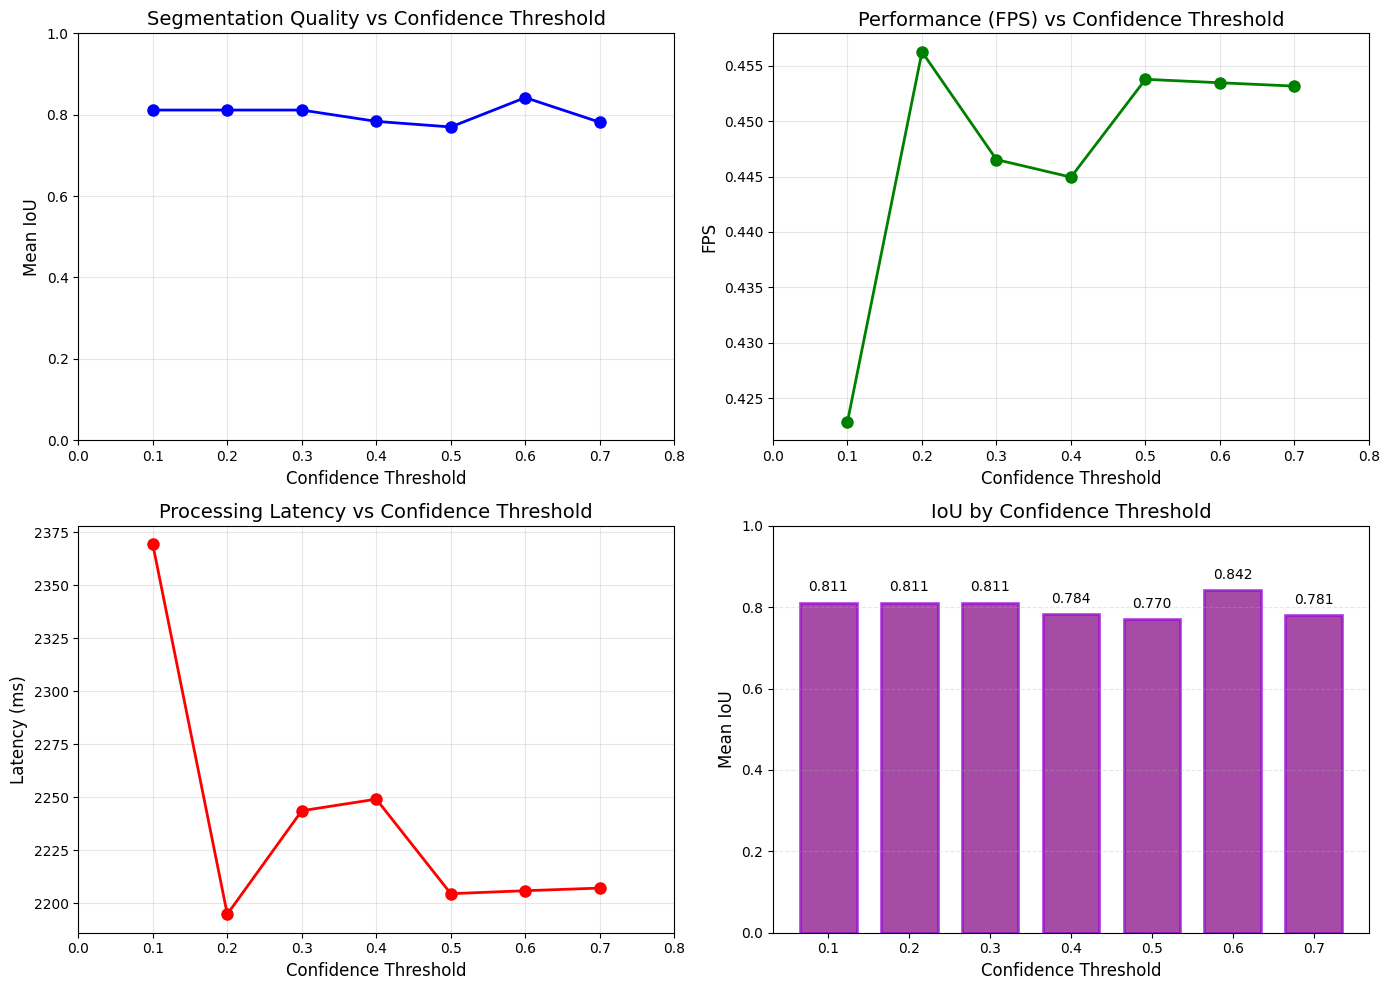


OPTIMAL THRESHOLD ANALYSIS
Threshold 0.1: IoU=0.811 ± 0.167, FPS=0.42, Latency=2369ms
Threshold 0.2: IoU=0.811 ± 0.167, FPS=0.46, Latency=2195ms
Threshold 0.3: IoU=0.811 ± 0.167, FPS=0.45, Latency=2244ms
Threshold 0.4: IoU=0.784 ± 0.256, FPS=0.44, Latency=2249ms
Threshold 0.5: IoU=0.770 ± 0.277, FPS=0.45, Latency=2204ms
Threshold 0.6: IoU=0.842 ± 0.144, FPS=0.45, Latency=2206ms
Threshold 0.7: IoU=0.781 ± 0.191, FPS=0.45, Latency=2207ms

🏆 Best trade-off: Threshold=0.6 (IoU=0.842, FPS=0.45)


In [ ]:
def plot_threshold_analysis(results_by_threshold):
    """Построение графиков зависимости от threshold"""

    thresholds = sorted(results_by_threshold.keys())

    # Извлекаем метрики
    mean_ious = [results_by_threshold[t]['statistics']['mean_iou'] for t in thresholds]
    std_ious = [results_by_threshold[t]['statistics']['std_iou'] for t in thresholds]
    mean_fps = [results_by_threshold[t]['statistics']['mean_fps'] for t in thresholds]
    mean_latency = [results_by_threshold[t]['statistics']['mean_total_time_ms'] for t in thresholds]

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # 1. IoU vs Threshold
    axes[0, 0].errorbar(thresholds, mean_ious,
                        fmt='o-', capthick=2,
                        color='blue', markersize=8, linewidth=2)
    axes[0, 0].set_xlabel('Confidence Threshold', fontsize=12)
    axes[0, 0].set_ylabel('Mean IoU', fontsize=12)
    axes[0, 0].set_title('Segmentation Quality vs Confidence Threshold', fontsize=14)
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].set_xlim([0, 0.8])
    axes[0, 0].set_ylim([0, 1])

    # 2. FPS vs Threshold
    axes[0, 1].plot(thresholds, mean_fps, 'o-', color='green',
                    markersize=8, linewidth=2)
    axes[0, 1].set_xlabel('Confidence Threshold', fontsize=12)
    axes[0, 1].set_ylabel('FPS', fontsize=12)
    axes[0, 1].set_title('Performance (FPS) vs Confidence Threshold', fontsize=14)
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].set_xlim([0, 0.8])

    # 3. Latency vs Threshold
    axes[1, 0].plot(thresholds, mean_latency, 'o-', color='red',
                    markersize=8, linewidth=2)
    axes[1, 0].set_xlabel('Confidence Threshold', fontsize=12)
    axes[1, 0].set_ylabel('Latency (ms)', fontsize=12)
    axes[1, 0].set_title('Processing Latency vs Confidence Threshold', fontsize=14)
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].set_xlim([0, 0.8])

    # 4. ГИСТОГРАММА: IoU vs Threshold (вертикальная гистограмма)
    # Сортируем по threshold для лучшей визуализации
    sorted_pairs = sorted(zip(thresholds, mean_ious, std_ious))
    sorted_thresholds = [p[0] for p in sorted_pairs]
    sorted_ious = [p[1] for p in sorted_pairs]
    sorted_stds = [p[2] for p in sorted_pairs]

    # Создаем вертикальные бары с промежутками
    x = np.arange(len(sorted_thresholds))
    width = 0.7  # Ширина столбца (0.7 = есть промежутки 0.3)

    bars = axes[1, 1].bar(x, sorted_ious, width,
                          color='purple', alpha=0.7,
                          edgecolor='darkviolet', linewidth=2)

    # Добавляем значения на бары
    for i, (bar, iou, std, th) in enumerate(zip(bars, sorted_ious, sorted_stds, sorted_thresholds)):
        height = bar.get_height()
        axes[1, 1].text(bar.get_x() + bar.get_width()/2, height + 0.02,
                      f'{iou:.3f}',
                      ha='center', va='bottom', fontsize=10)

    # Настройка осей
    axes[1, 1].set_xlabel('Confidence Threshold', fontsize=12)
    axes[1, 1].set_ylabel('Mean IoU', fontsize=12)
    axes[1, 1].set_title('IoU by Confidence Threshold', fontsize=14)
    axes[1, 1].set_xticks(x)
    axes[1, 1].set_xticklabels(sorted_thresholds, fontsize=10)
    axes[1, 1].set_ylim([0, 1])
    axes[1, 1].grid(True, alpha=0.3, axis='y', linestyle='--')

    plt.tight_layout()
    plt.show()

    # Вывод оптимального порога
    print("\n" + "="*60)
    print("OPTIMAL THRESHOLD ANALYSIS")
    print("="*60)
    for i, th in enumerate(thresholds):
        print(f"Threshold {th}: IoU={mean_ious[i]:.3f} ± {std_ious[i]:.3f}, "
              f"FPS={mean_fps[i]:.2f}, Latency={mean_latency[i]:.0f}ms")

    # Находим best trade-off (максимизируем IoU + FPS)
    scores = [mean_ious[i] * mean_fps[i] for i in range(len(thresholds))]
    best_idx = np.argmax(scores)
    print(f"\n Best trade-off: Threshold={thresholds[best_idx]} "
          f"(IoU={mean_ious[best_idx]:.3f}, FPS={mean_fps[best_idx]:.2f})")

# Построение графиков (после сбора данных)
plot_threshold_analysis(results_by_threshold)

In [ ]:
# ============================================
# ВАРИАНТ 1: Тестирование одного промпта
# ============================================

results, latencies, inference_times, fps_list = tester.run_batch_test(
    images_dir=images_dir,
    masks_dir=masks_dir,
    prompt=PROMPT,
    confidence_threshold=0.6,
    num_images=NUM_IMAGES,
    resize=RESIZE
    )

# Сохранение результатов
if results:
        output = {
            'prompt': "car",
            'num_images': len(results),
            'results': results,
            'statistics': {
                'mean_iou': float(np.mean([r['iou'] for r in results])),
                'mean_inference_time_ms': float(np.mean(inference_times)),
                'mean_total_time_ms': float(np.mean(latencies)) * 1000,
                'mean_fps': float(np.mean(fps_list))
            }
        }

        with open(f'/content/test_results_{PROMPT}_threshold-{threshold}.json', 'w') as f:
            json.dump(output, f, indent=2)

# Финальная очистка
segmenter.clear_memory()

BATCH TEST: 10 images
Prompt: 'car', Threshold: 0.1

Found 10 valid image-mask pairs


------------------------------------------------------------
Processing image 1/10

Testing: 7d15b18b-1e0d6e3f.jpg
Prompt: 'car', Threshold: 0.1
Target classes: car (IDs: [13])
GT car pixels: 40414
DEBUG: masks shape = torch.Size([9, 1, 1008, 1008]), dim = 4
DEBUG: scores shape = torch.Size([9])
DEBUG: 4D tensor, num_masks=9, channels=1
Found 9 objects for prompt: 'car'
  Object 1: confidence=0.368, processing...
  Object 2: confidence=0.314, processing...
  Object 3: confidence=0.438, processing...
  Object 4: confidence=0.383, processing...
  Object 5: confidence=0.582, processing...
  Object 6: confidence=0.314, processing...
  Object 7: confidence=0.451, processing...
  Object 8: confidence=0.468, processing...
  Object 9: confidence=0.335, processing...
Successfully processed 9 objects

📊 Detection Results:
  Detected objects: 9
    Object 1: confidence = 0.368
    Object 2: confidence = 0.314
 

Running full image segmentation...
Found 3 objects for prompt: 'road surface'
Found 6 objects for prompt: 'sidewalk or pavement'
Found 13 objects for prompt: 'building or house'
Found 6 objects for prompt: 'wall or fence wall'
No objects found for prompt: 'fence or railing'
Found 36 objects for prompt: 'pole or street pole'
Found 1 objects for prompt: 'traffic light'
Found 6 objects for prompt: 'traffic sign or road sign'
Found 29 objects for prompt: 'vegetation or trees'
No objects found for prompt: 'terrain or ground surface'
Found 1 objects for prompt: 'sky'
No objects found for prompt: 'person'
No objects found for prompt: 'rider on motorcycle or bicycle'
Found 29 objects for prompt: 'car'
No objects found for prompt: 'truck'
Found 2 objects for prompt: 'bus'
Found 2 objects for prompt: 'train'
No objects found for prompt: 'motorcycle'
No objects found for prompt: 'bicycle'

FULL SEGMENTATION PERFORMANCE
Total time for all 19 classes: 44227.11 ms
Average time per class: 2327.74 ms


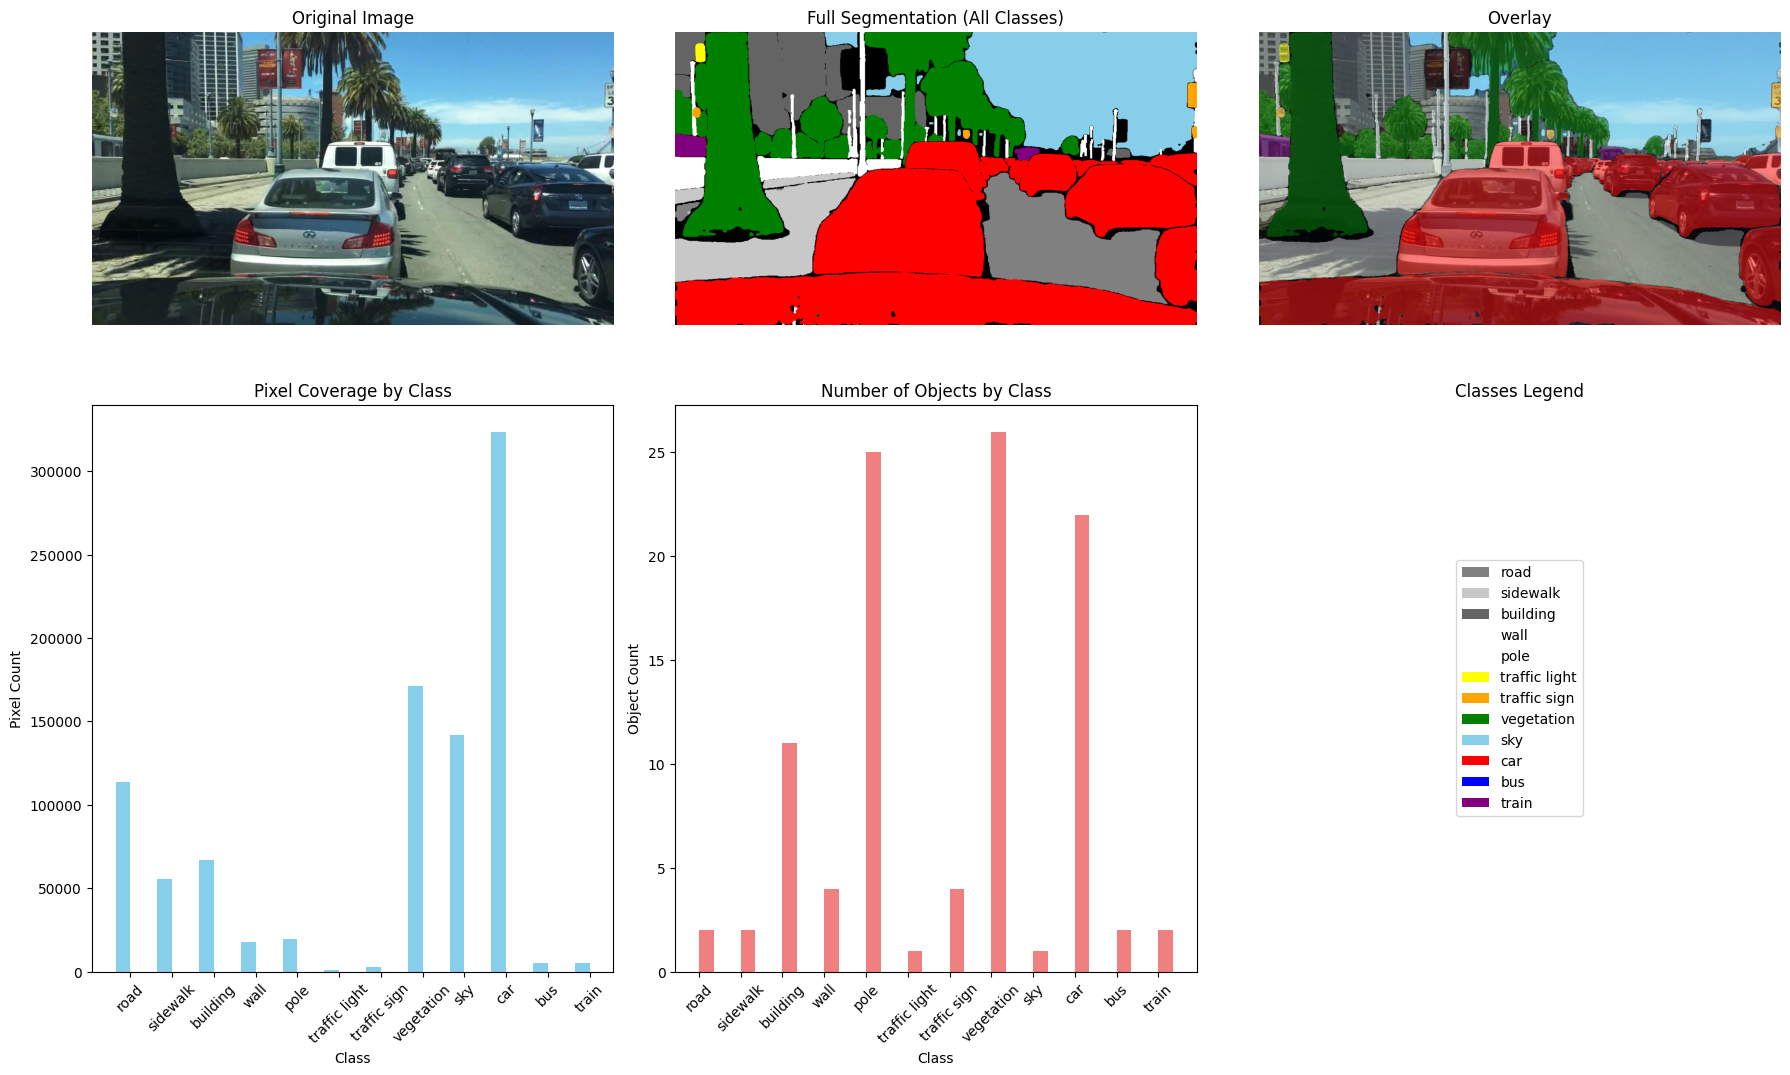


Comparing with Ground Truth...

ROAD:
  IoU: 0.6535
  GT pixels: 83587, Pred pixels: 113948
  Objects: 2

SIDEWALK:
  IoU: 0.8851
  GT pixels: 60334, Pred pixels: 55283
  Objects: 2

BUILDING:
  IoU: 0.8465
  GT pixels: 70938, Pred pixels: 66645
  Objects: 11

WALL:
  IoU: 0.9209
  GT pixels: 18793, Pred pixels: 17882
  Objects: 4

FENCE:
  IoU: 0.0000
  GT pixels: 0, Pred pixels: 0
  Objects: 0

POLE:
  IoU: 0.5210
  GT pixels: 12816, Pred pixels: 19678
  Objects: 25

TRAFFIC LIGHT:
  IoU: 0.0000
  GT pixels: 0, Pred pixels: 1069
  Objects: 1

TRAFFIC SIGN:
  IoU: 0.5350
  GT pixels: 1377, Pred pixels: 2502
  Objects: 4

VEGETATION:
  IoU: 0.8150
  GT pixels: 166608, Pred pixels: 171489
  Objects: 26

TERRAIN:
  IoU: 0.0000
  GT pixels: 0, Pred pixels: 0
  Objects: 0

SKY:
  IoU: 0.9338
  GT pixels: 147410, Pred pixels: 141970
  Objects: 1

PERSON:
  IoU: 0.0000
  GT pixels: 0, Pred pixels: 0
  Objects: 0

RIDER:
  IoU: 0.0000
  GT pixels: 0, Pred pixels: 0
  Objects: 0

CAR:
  IoU: 

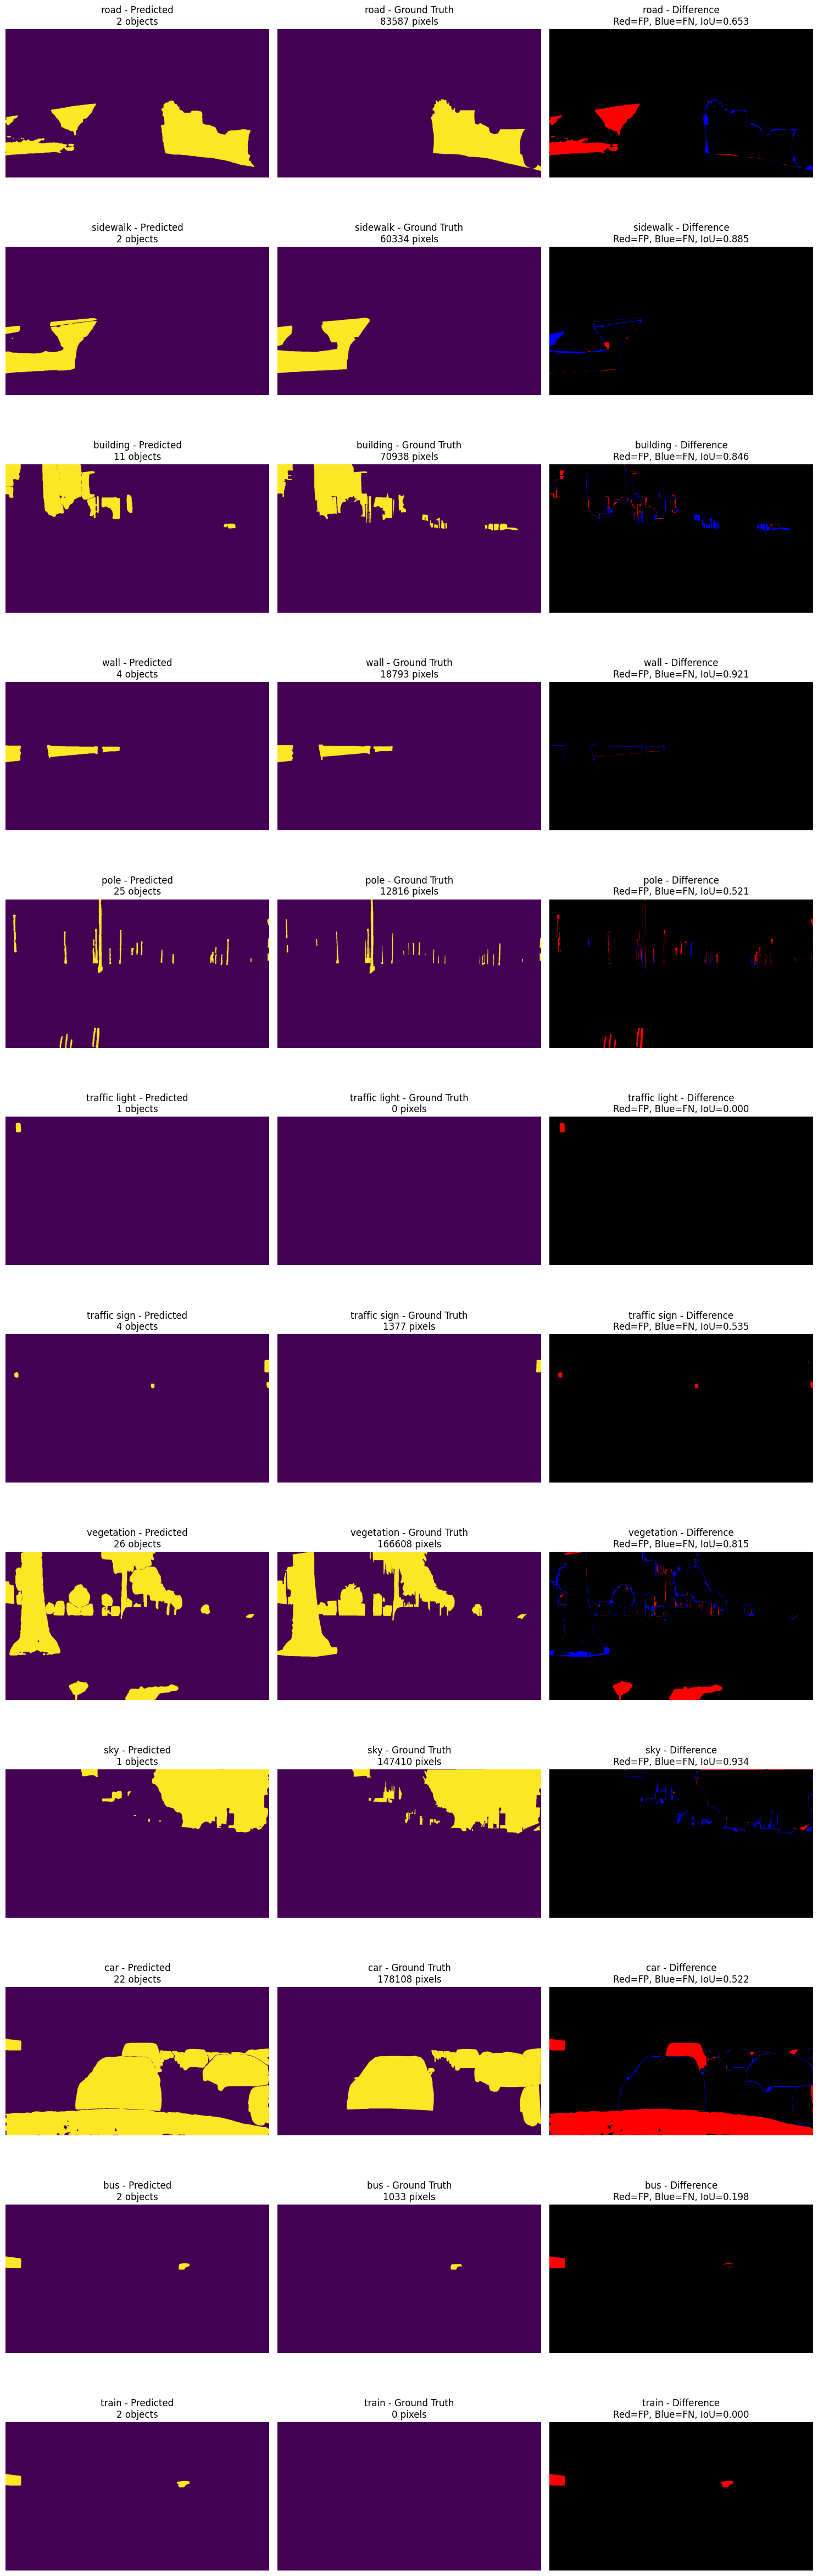

Detected classes:

 - road

 - sidewalk

 - building

 - wall

 - pole

 - traffic light

 - traffic sign

 - vegetation

 - sky

 - car

 - bus

 - train


In [ ]:
# Загружаем изображение для тестирования
test_image_path = images_dir / '7df23ae0-00000000.jpg'
test_mask_path = masks_dir / '7df23ae0-00000000_train_color.png'

# Открываем изображение
image = Image.open(test_image_path).convert('RGB')

# 1. Полная сегментация
print("Running full image segmentation...")
full_seg, combined_mask, _ = segmenter.segment_full_image(
    image,
    confidence_threshold=0.6,
)

# 2. Визуализация результатов
print("\nVisualizing results...")
segmenter.visualize_full_segmentation(image, full_seg, combined_mask)

# 3. Сравнение с Ground Truth
print("\nComparing with Ground Truth...")
metrics = segmenter.compare_with_gt_full(full_seg, test_mask_path)

# 4. Детальное сравнение по классам
print("\nDetailed class comparison...")
segmenter.visualize_class_comparison(image, full_seg, test_mask_path)

# 5. Сохраняем результаты
results_summary = {
    'image': str(test_image_path),
    'classes_detected': {name: data['num_objects'] for name, data in full_seg.items() if data['num_objects'] > 0},
    'total_pixels_segmented': int(combined_mask.sum()),  # общее количество сегментированных пикселей
    'segmentation_percentage': float(combined_mask.sum() / (image.height * image.width)),
    'metrics': metrics
}

import json
with open('/content/full_segmentation_results.json', 'w') as f:
    json.dump(results_summary, f, indent=2)

print("Detected classes:")

for name, data in full_seg.items():
    if data['num_objects'] > 0:

      print(f"\n - {name}")